### Outliers

An outlier is a data point that is significantly different from the rest of the observations in a dataset. It sits far away from the main crowd of data points, acting as an anomaly or an extreme exception to the general pattern.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

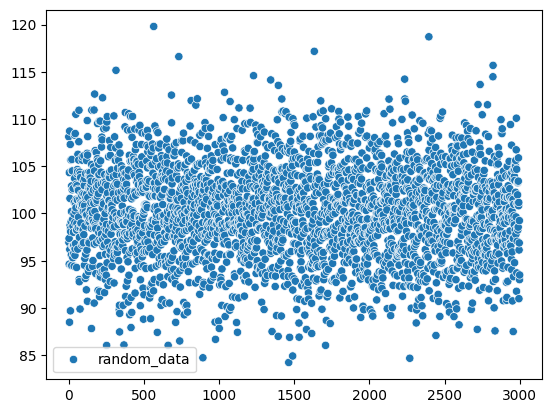

In [39]:
np.random.seed(1)
data_1 = 5 * np.random.randn(3000) +100
df = pd.DataFrame(data_1, columns=["random_data"])
# sns.displot(df)
sns.scatterplot(df)
plt.show()

### Getting mean and standard devation to remove outliers

In [ ]:


data_mean = df["random_data"].mean()
print(data_mean)
data_std = df["random_data"].std()
print(data_std) 

100.07328224658676
4.97534586972072


### Removing the outliers with the value greater than the standard devation using Z-Score method

random_data    140
dtype: int64


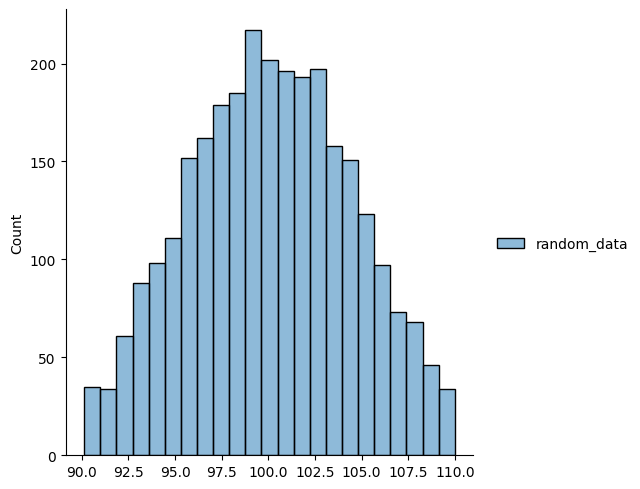

In [19]:
lower_bound = -2*data_std + data_mean
upper_bound = 2*data_std + data_mean

outliers = df[(df["random_data"] < lower_bound) | (df["random_data"] > upper_bound)]
print(outliers.count())

clean_data = df[(df["random_data"] > lower_bound) & (df["random_data"] < upper_bound)]
sns.displot(clean_data)


### Visualizing outliers and remove using IQR(Interquartile range)

Text(0.5, 1.0, 'Data points')

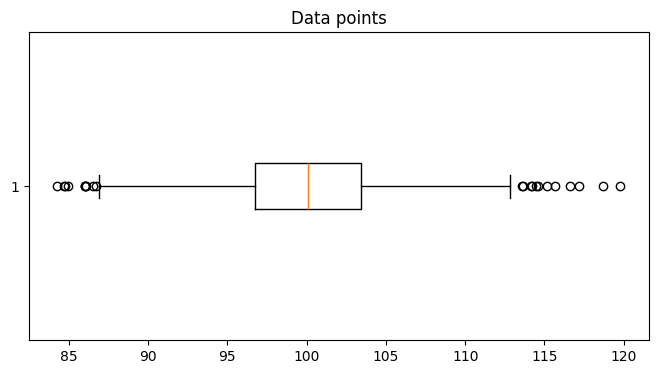

In [25]:
fig = plt.figure(figsize= (8,4))
plt.boxplot(df, vert=False)
plt.title("Data points")


{'whiskers': [<matplotlib.lines.Line2D at 0x162bbdca5d0>,
 'caps': [<matplotlib.lines.Line2D at 0x162bbdca850>,
 'boxes': [<matplotlib.lines.Line2D at 0x162bbdca490>],
 'medians': [<matplotlib.lines.Line2D at 0x162bbdcaad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x162bbdcac10>],
 'means': []}

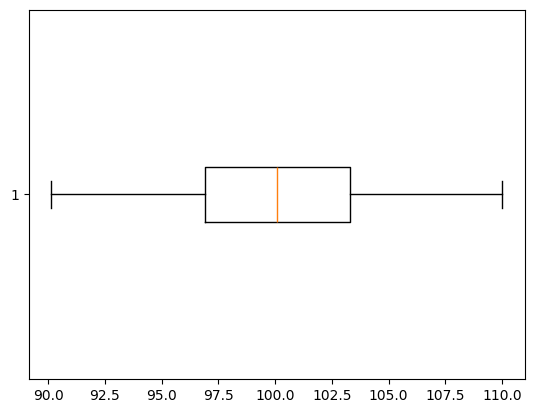

In [24]:
plt.boxplot(clean_data, vert=False)

In [ ]:
def outlier_detectioin(df : pd.DataFrame):
    sorted_df = df.sort_values(by = ["random_data"])
    Q1 = sorted_df["random_data"].quantile(0.25)
    Q3 = sorted_df["random_data"].quantile(0.75)
    IQR = Q3 - Q1
    buffer_zone = 1.5 * IQR
    lower_bound = Q1 - buffer_zone
    upper_bound = Q3 + buffer_zone
    outliers = df[(df["random_data"] < lower_bound) | (df["random_data"] > upper_bound)]
    clean_df = df[(df["random_data"] > lower_bound) & (df["random_data"] < upper_bound)] 
    fig= plt.figure(figsize=(8,4))
    plt.boxplot(clean_df, vert=False)    # cleaned data without outlier
    # plt.boxplot(outliers, vert=False)  # uncleaned data with outlier
    

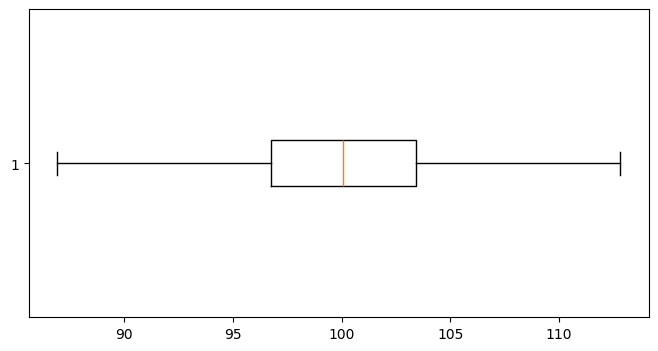

In [35]:
outlier_detectioin(df)